In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from dataclasses import dataclass
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import math

In [9]:
@dataclass
class ViTConfig:
    num_hidden_layers: int = 4
    num_channels: int = 3
    image_size: int = 32
    patch_size: int = 4
    num_attention_heads: int = 4
    hidden_size: int = 256
    intermediate_size: int = 1024
    num_classes: int = 10
    layer_norm_eps: float = 1e-6
    attention_dropout: float = 0.1
    dropout: float = 0.1

def get_cifar10_transforms():
    train_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomCrop(32, padding=4),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                             std=[0.2470, 0.2435, 0.2616])
    ])
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                             std=[0.2470, 0.2435, 0.2616])
    ])
    return train_transform, test_transform

In [10]:
class PatchEmbeddings(nn.Module):
    def __init__(self, config: ViTConfig):
        super().__init__()
        self.embed_dim    = config.hidden_size
        self.patch_size   = config.patch_size
        self.num_patches  = (config.image_size // config.patch_size) ** 2
        self.num_positions = self.num_patches + 1

        self.projection = nn.Conv2d(
            in_channels=config.num_channels,
            out_channels=self.embed_dim,
            kernel_size=config.patch_size,
            stride=config.patch_size,
            padding='valid'
        )

        self.cls_token = nn.Parameter(torch.zeros(1, 1, self.embed_dim))
        self.position_embedding = nn.Embedding(self.num_positions, self.embed_dim)
        self.register_buffer(
            "position_ids",
            torch.arange(self.num_positions).expand(1, -1),
            persistent=False
        )
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, pixel_values: torch.FloatTensor) -> torch.Tensor:
        B = pixel_values.shape[0]
        x = self.projection(pixel_values)
        x = x.flatten(2).transpose(1, 2)

        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.position_embedding(self.position_ids)
        return self.dropout(x)

In [11]:
class MultiHeadAttention(nn.Module):
    def __init__(self, config: ViTConfig):
        super().__init__()
        self.num_heads       = config.num_attention_heads
        self.embed_dim       = config.hidden_size
        self.head_dim        = self.embed_dim // self.num_heads
        self.attn_dropout    = config.attention_dropout

        self.q_proj  = nn.Linear(self.embed_dim, self.embed_dim)
        self.k_proj  = nn.Linear(self.embed_dim, self.embed_dim)
        self.v_proj  = nn.Linear(self.embed_dim, self.embed_dim)
        self.out_proj = nn.Linear(self.embed_dim, self.embed_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape
        q = self.q_proj(x).view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        attn = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        attn = F.softmax(attn, dim=-1)
        attn = F.dropout(attn, p=self.attn_dropout, training=self.training)

        out = (attn @ v).transpose(1, 2).reshape(B, T, C)
        return self.out_proj(out)

In [12]:
class MLPBlock(nn.Module):
    def __init__(self, config: ViTConfig):
        super().__init__()
        self.fc1     = nn.Linear(config.hidden_size, config.intermediate_size)
        self.fc2     = nn.Linear(config.intermediate_size, config.hidden_size)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = F.gelu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [13]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, config: ViTConfig):
        super().__init__()
        self.norm1   = nn.LayerNorm(config.hidden_size, eps=config.layer_norm_eps)
        self.attn    = MultiHeadAttention(config)
        self.norm2   = nn.LayerNorm(config.hidden_size, eps=config.layer_norm_eps)
        self.mlp     = MLPBlock(config)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

In [14]:
class VisionTransformer(nn.Module):
    def __init__(self, config: ViTConfig):
        super().__init__()
        self.embeddings = PatchEmbeddings(config)
        self.encoder    = nn.ModuleList([
            TransformerEncoderBlock(config) for _ in range(config.num_hidden_layers)
        ])
        self.norm       = nn.LayerNorm(config.hidden_size, eps=config.layer_norm_eps)
        self.classifier = nn.Linear(config.hidden_size, config.num_classes)

    def forward(self, pixel_values: torch.Tensor) -> torch.Tensor:
        x = self.embeddings(pixel_values)
        for block in self.encoder:
            x = block(x)
        x = self.norm(x)
        cls_output = x[:, 0]
        return self.classifier(cls_output)

Epoch 1/20: 100%|██████████| 196/196 [00:41<00:00,  4.68it/s, Loss=1.778, Acc=30.1%]


Epoch 1: Train Acc: 30.13%  Test Acc: 40.45%


Epoch 2/20: 100%|██████████| 196/196 [00:42<00:00,  4.63it/s, Loss=1.542, Acc=41.0%]


Epoch 2: Train Acc: 40.96%  Test Acc: 47.68%


Epoch 3/20: 100%|██████████| 196/196 [00:42<00:00,  4.64it/s, Loss=1.811, Acc=45.0%]


...

Epoch 18: Train Acc: 66.13%  Test Acc: 68.13%


Epoch 19/20: 100%|██████████| 196/196 [00:42<00:00,  4.62it/s, Loss=1.092, Acc=66.8%]


Epoch 19: Train Acc: 66.81%  Test Acc: 68.93%


Epoch 20/20: 100%|██████████| 196/196 [00:42<00:00,  4.60it/s, Loss=1.287, Acc=67.9%]


Epoch 20: Train Acc: 67.90%  Test Acc: 70.02%

Best Test Accuracy: 70.02%


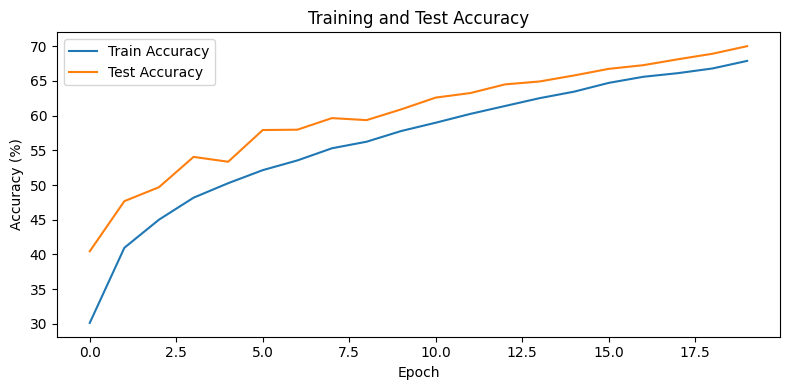

In [15]:
def main():
    train_transform, test_transform = get_cifar10_transforms()

    trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                             download=True, transform=train_transform)
    testset  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                             download=True, transform=test_transform)

    trainloader = DataLoader(trainset, batch_size=256, shuffle=True,
                             num_workers=2, pin_memory=True)
    testloader  = DataLoader(testset,  batch_size=256, shuffle=False,
                             num_workers=2, pin_memory=True)

    config    = ViTConfig()
    model     = VisionTransformer(config).cuda()
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.05)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

    num_epochs = 20
    best_acc   = 0.0
    train_accs, test_accs = [], []

    for epoch in range(num_epochs):
        model.train()
        train_loss = train_correct = train_total = 0

        pbar = tqdm(trainloader, desc=f'Epoch {epoch+1}/{num_epochs}')
        for inputs, targets in pbar:
            inputs, targets = inputs.cuda(), targets.cuda()
            optimizer.zero_grad()
            outputs = model(inputs)
            loss    = criterion(outputs, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss    += loss.item()
            _, predicted   = outputs.max(1)
            train_total   += targets.size(0)
            train_correct += predicted.eq(targets).sum().item()
            pbar.set_postfix({
                'Loss': f'{loss.item():.3f}',
                'Acc':  f'{100.*train_correct/train_total:.1f}%'
            })

        scheduler.step()

        model.eval()
        test_correct = test_total = 0
        with torch.no_grad():
            for inputs, targets in testloader:
                inputs, targets = inputs.cuda(), targets.cuda()
                outputs         = model(inputs)
                _, predicted    = outputs.max(1)
                test_total     += targets.size(0)
                test_correct   += predicted.eq(targets).sum().item()

        train_acc = 100. * train_correct / train_total
        test_acc  = 100. * test_correct  / test_total
        train_accs.append(train_acc)
        test_accs.append(test_acc)

        print(f'Epoch {epoch+1}: Train Acc: {train_acc:.2f}%  Test Acc: {test_acc:.2f}%')

        if test_acc > best_acc:
            best_acc = test_acc
            torch.save(model.state_dict(), 'best_vit_cifar10.pth')

    print(f'\nBest Test Accuracy: {best_acc:.2f}%')

    # plot training curves
    plt.figure(figsize=(8, 4))
    plt.plot(train_accs, label='Train Accuracy')
    plt.plot(test_accs,  label='Test Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('Training and Test Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.savefig('accuracy_curve.png')
    plt.show()

if __name__ == "__main__":
    main()